In [11]:
pip install tensorflow


Defaulting to user installation because normal site-packages is not writeable
You should consider upgrading via the '/Library/Developer/CommandLineTools/usr/bin/python3 -m pip install --upgrade pip' command.
Note: you may need to restart the kernel to use updated packages.



📌 Weight Distribution (EWM):
events.goals: 0.0599
events.assists: 0.0751
events.shots_on_target: 0.0407
events.key_passes: 0.0405
events.penalties_earned: 0.3652
touches.successful_passes: 0.3652
touches.take_on_successful: 0.0534

🌲 Weight Distribution (Random Forest):
events.goals: 0.0624
events.assists: 0.0117
events.shots_on_target: 0.3472
events.key_passes: 0.5026
events.penalties_earned: 0.0000
touches.successful_passes: 0.0000
touches.take_on_successful: 0.0762

⚡ Weight Distribution (XGBoost):
events.goals: 0.0382
events.assists: 0.0119
events.shots_on_target: 0.1727
events.key_passes: 0.7177
events.penalties_earned: 0.0000
touches.successful_passes: 0.0000
touches.take_on_successful: 0.0594


/Users/aranyabasu/Library/Python/3.9/lib/python/site-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)



🧠 Feature Importance (Deep Learning):
events.goals: 0.1398
events.assists: 0.1676
events.shots_on_target: 0.1326
events.key_passes: 0.1620
events.penalties_earned: 0.1240
touches.successful_passes: 0.1334
touches.take_on_successful: 0.1406


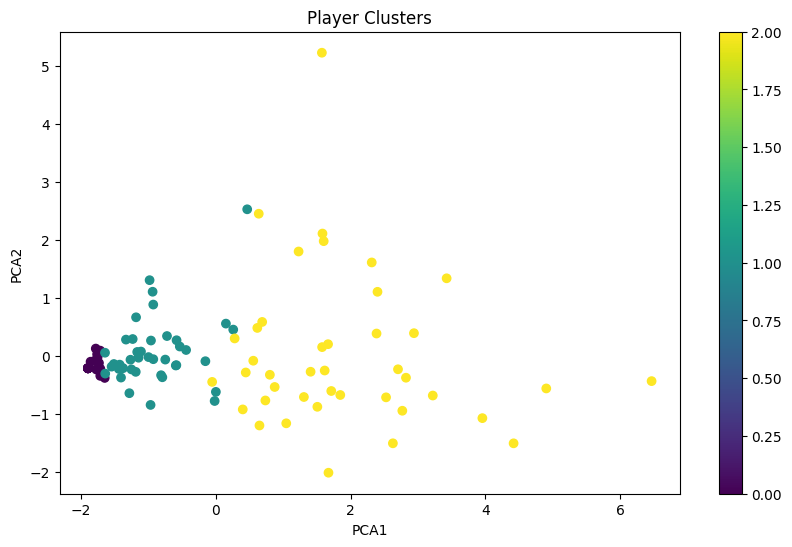


Top 10 Players (EWM)
                                 name            team_name  Score_EWM
313                      Roy Krishna      ATK Mohun Bagan   4.690444
54                       Roy Krishna               ATK FC   3.883528
536  Luis Miguel Vieira Babo Machado  NorthEast United FC   3.786728
348                Bright Enobakhare       SC East Bengal   3.547171
126        Ferran Corominas Telechea               FC Goa   3.352573
20                   Nerijus Valskis        Chennaiyin FC   3.334658
113            Marcelo Leite Pereira         Hyderabad FC   3.237857
544  Diego Mauricio Machado de Brito            Odisha FC   3.176134
540                    Jordan Murray   Kerala Blasters FC   3.058026
220              Bartholomew Ogbeche   Kerala Blasters FC   3.009292

Top 10 Players (RF)
                                 name            team_name   Score_RF
313                      Roy Krishna      ATK Mohun Bagan  29.424821
536  Luis Miguel Vieira Babo Machado  NorthEast United FC 

/var/folders/9z/vml81xxs78lclpgzq0t4l7sr0000gn/T/ipykernel_98075/3714302290.py:370: RuntimeWarning: invalid value encountered in divide
  values1_norm=values1/max_vals
/var/folders/9z/vml81xxs78lclpgzq0t4l7sr0000gn/T/ipykernel_98075/3714302290.py:371: RuntimeWarning: invalid value encountered in divide
  values2_norm=values2/max_vals


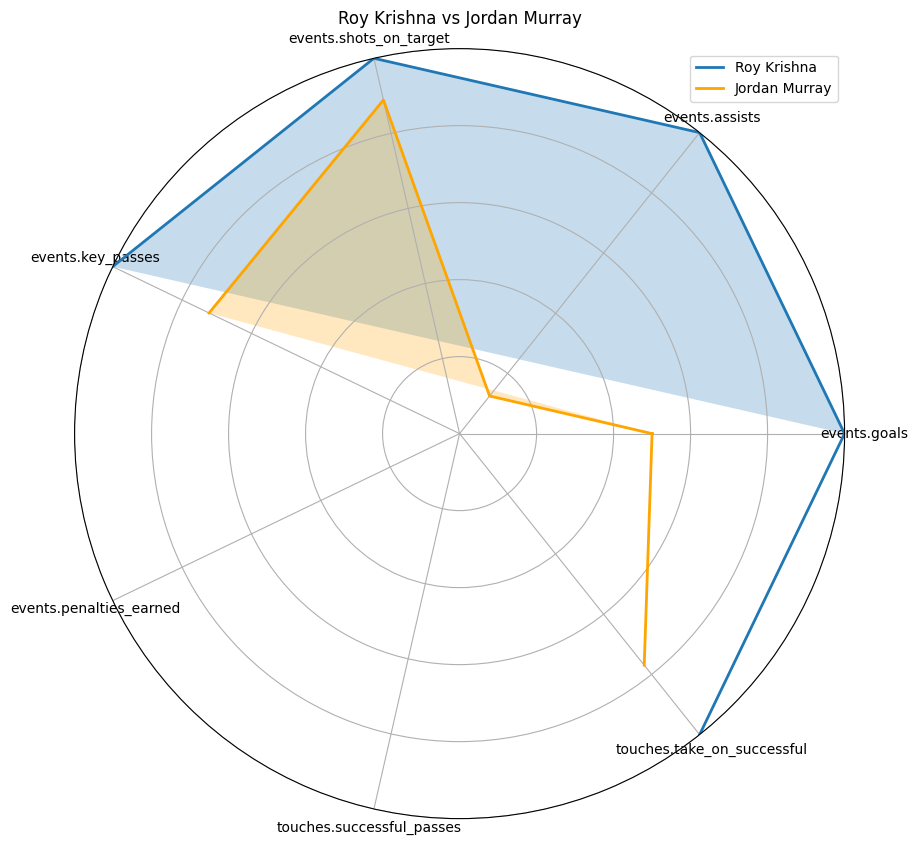

In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from math import pi

from sklearn.cluster import SpectralClustering
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.ensemble import RandomForestRegressor

from xgboost import XGBRegressor

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.optimizers import Adam


# =========================
# 1. Load and Clean Data
# =========================

def load_data(file_path):

    df = pd.read_csv(file_path)

    df.columns = df.columns.str.strip().str.replace('\ufeff','')

    df['name'] = df['name'].astype(str).str.strip()
    df['team_name'] = df['team_name'].astype(str).str.strip()
    df['position_short'] = df['position_short'].astype(str).str.upper().str.strip()

    df['position_short'] = df['position_short'].replace({
        'F':'FW','FWD':'FW','ST':'FW',
        'M':'MF','MID':'MF',
        'D':'DF','DEF':'DF',
        'GK':'GK','G':'GK'
    })

    df.fillna(0,inplace=True)

    return df


# =========================
# 2. Radar Chart
# =========================

def plot_radar(player1_stats, player2_stats, stats_labels, player1, player2):

    angles = [n/float(len(stats_labels))*2*pi for n in range(len(stats_labels))]
    angles += angles[:1]

    player1_stats = np.append(player1_stats,player1_stats[0])
    player2_stats = np.append(player2_stats,player2_stats[0])

    fig, ax = plt.subplots(figsize=(12,10),subplot_kw=dict(polar=True))

    ax.plot(angles,player1_stats,linewidth=2,label=player1)
    ax.fill(angles,player1_stats,alpha=0.25)

    ax.plot(angles,player2_stats,linewidth=2,label=player2,color='orange')
    ax.fill(angles,player2_stats,alpha=0.25,color='orange')

    ax.set_xticks(angles[:-1])
    ax.set_xticklabels(stats_labels)

    ax.set_yticklabels([])
    ax.set_ylim(0,1)

    plt.title(f"{player1} vs {player2}")
    plt.legend()
    plt.show()


# =========================
# 3. Weight Computation
# =========================

def compute_ewm_weights(X):

    data = X.astype(float).values

    col_sums = np.maximum(data.sum(axis=0),1e-12)

    P = data/col_sums

    n = P.shape[0]

    k = 1/np.log(n)

    entropy = -k*np.nansum(P*np.log(P+1e-12),axis=0)

    divergence = 1-entropy

    weights = divergence/divergence.sum()

    return weights


def compute_rf_weights(X):

    X_numeric = X.astype(float)

    y = X_numeric.sum(axis=1)

    rf = RandomForestRegressor(n_estimators=300,random_state=42)

    rf.fit(X_numeric,y)

    weights = rf.feature_importances_

    weights = weights/weights.sum()

    return weights


def compute_xgb_weights(X):

    X_numeric = X.astype(float)

    y = X_numeric.sum(axis=1)

    xgb = XGBRegressor(
        n_estimators=400,
        learning_rate=0.05,
        max_depth=4,
        random_state=42,
        objective='reg:squarederror'
    )

    xgb.fit(X_numeric,y)

    weights = xgb.feature_importances_

    weights = weights/weights.sum()

    return weights


# =========================
# Deep Learning Weights
# =========================

def compute_dl_weights(X):

    X_numeric = X.astype(float).values

    y = X_numeric.sum(axis=1)

    scaler = StandardScaler()

    X_scaled = scaler.fit_transform(X_numeric)

    model = Sequential([
        Dense(32,activation='relu',input_shape=(X_scaled.shape[1],)),
        Dense(16,activation='relu'),
        Dense(8,activation='relu'),
        Dense(1)
    ])

    model.compile(
        optimizer=Adam(learning_rate=0.001),
        loss='mse'
    )

    model.fit(
        X_scaled,
        y,
        epochs=80,
        batch_size=16,
        verbose=0
    )

    weights = np.abs(model.layers[0].get_weights()[0]).mean(axis=1)

    weights = weights/weights.sum()

    return weights


# =========================
# 4. Main Script
# =========================

def main():

    file_path = r"/Users/aranyabasu/Desktop/dataanalysislearning/project_final/source_code/final_year_project_dataset.csv"

    df = load_data(file_path)

    position_input = input("Enter position (FW, MF, DF, GK): ").strip().upper()

    if position_input == 'FW':

        stats = [
            'events.goals','events.assists','events.shots_on_target',
            'events.key_passes','events.penalties_earned',
            'touches.successful_passes','touches.take_on_successful'
        ]

    elif position_input == 'MF':

        stats = [
            'events.assists','events.key_passes','events.chances_created',
            'touches.successful_passes','touches.interceptions','events.goals'
        ]

    elif position_input == 'DF':

        stats = [
            'touches.tackles','touches.blocks','touches.interceptions',
            'touches.clearance','events.cleansheet','touches.successful_passes'
        ]

    elif position_input == 'GK':

        stats = [
            'goaltenders.saves','goaltenders.shots_faced',
            'events.cleansheet','goaltenders.penalty_kicks.saves',
            'goaltenders.goals_allowed'
        ]

    position_df = df[df['position_short']==position_input].copy()

    X = position_df[stats].astype(float)


    # =========================
    # Weight Computations
    # =========================

    weights_ewm = compute_ewm_weights(X)
    print("\n📌 Weight Distribution (EWM):")
    for s, w in zip(stats, weights_ewm):
        print(f"{s}: {w:.4f}")
    position_df['Score_EWM'] = X.dot(weights_ewm)

    weights_rf = compute_rf_weights(X)
    print("\n🌲 Weight Distribution (Random Forest):")
    for s, w in zip(stats, weights_rf):
        print(f"{s}: {w:.4f}")
    position_df['Score_RF'] = X.dot(weights_rf)

    weights_xgb = compute_xgb_weights(X)
    print("\n⚡ Weight Distribution (XGBoost):")
    for s, w in zip(stats, weights_xgb):
        print(f"{s}: {w:.4f}")
    position_df['Score_XGB'] = X.dot(weights_xgb)

    weights_dl = compute_dl_weights(X)
    print("\n🧠 Feature Importance (Deep Learning):")
    for s, w in zip(stats, weights_dl):
        print(f"{s}: {w:.4f}")
    position_df['Score_DL'] = X.dot(weights_dl)


    # =========================
    # Spectral Clustering
    # =========================

    scaler = StandardScaler()
    scaled_features = scaler.fit_transform(X)

    spectral = SpectralClustering(
        n_clusters=3,
        affinity='nearest_neighbors',
        random_state=42
    )

    position_df['Cluster'] = spectral.fit_predict(scaled_features)


    # =========================
    # PCA Visualization
    # =========================

    pca = PCA(n_components=2)

    pca_result = pca.fit_transform(scaled_features)

    plt.figure(figsize=(10,6))

    scatter = plt.scatter(
        pca_result[:,0],
        pca_result[:,1],
        c=position_df['Cluster'],
        cmap='viridis'
    )

    plt.title("Player Clusters")
    plt.xlabel("PCA1")
    plt.ylabel("PCA2")

    plt.colorbar(scatter)

    plt.show()


    # =========================
    # Top 10 Players
    # =========================

    def get_top10(score):

        top = position_df.sort_values(by=score,ascending=False)

        return top[['name','team_name',score]].head(10),top

    top10_ewm,players_ewm = get_top10('Score_EWM')
    top10_rf,players_rf = get_top10('Score_RF')
    top10_xgb,players_xgb = get_top10('Score_XGB')
    top10_dl,players_dl = get_top10('Score_DL')


    print("\nTop 10 Players (EWM)\n",top10_ewm)
    print("\nTop 10 Players (RF)\n",top10_rf)
    print("\nTop 10 Players (XGB)\n",top10_xgb)
    print("\nTop 10 Players (DL)\n",top10_dl)


    # =========================
    # Choose Ranking Method
    # =========================

    method = input("\nChoose ranking method (EWM, RF, XGB, DL): ").upper()

    if method == 'EWM':
        score_col='Score_EWM'
        players=players_ewm
    elif method=='RF':
        score_col='Score_RF'
        players=players_rf
    elif method=='XGB':
        score_col='Score_XGB'
        players=players_xgb
    else:
        score_col='Score_DL'
        players=players_dl


    # =========================
    # Player Comparison
    # =========================

    player1=input("\nEnter first player: ")
    player2=input("Enter second player: ")

    player1 = player1.strip()
    player2 = player2.strip()

    players['name'] = players['name'].astype(str).str.strip()

    row1 = players[players['name'].str.lower() == player1.lower()]
    row2 = players[players['name'].str.lower() == player2.lower()]

    if row1.empty:
        print(f"Player '{player1}' not found.")
        return

    if row2.empty:
        print(f"Player '{player2}' not found.")
        return

    values1 = row1.iloc[0][stats].values.astype(float)
    values2 = row2.iloc[0][stats].values.astype(float)

    max_vals=np.maximum(values1,values2)

    values1_norm=values1/max_vals
    values2_norm=values2/max_vals

    plot_radar(values1_norm,values2_norm,stats,player1,player2)


if __name__ == "__main__":
    main()